In [1]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [2]:
import os, sys
sys.path.append("..")

import torch
import wandb
from tqdm import tqdm

from src.light_gcot import LightGCOT
from src.distributions import StandardNormalSampler, SwissRollSampler

In [3]:
torch.set_default_tensor_type(torch.DoubleTensor)

/Users/michael/miniconda3/envs/light-gcot/lib/python3.12/site-packages/torch/__init__.py:749: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1718580122180/work/torch/csrc/tensor/python_tensor.cpp:433.)
  _C._set_default_tensor_type(t)


## 2. Config

In [4]:
X_DIM = 2
Y_DIM = 2
assert X_DIM > 1
# assert Y_DIM > 1

OUTPUT_SEED = 42

N_POTENTIALS = 500
M_POTENTIALS = 10
INIT_BY_SAMPLES = False
A_DIAGONAL_INIT = 0.1
IS_B_DIAGONAL = True

BATCH_SIZE = 128
SAMPLING_BATCH_SIZE = 128

EPSILON = 0.01

D_LR = 3e-4 # 1e-3 for eps 0.1, 0.01 and 3e-4 for eps 0.002
D_GRADIENT_MAX_NORM = float('inf')

PLOT_EVERY = 500
MAX_STEPS = 20000
CONTINUE = -1

In [5]:
torch.manual_seed(OUTPUT_SEED)

In [6]:
EXP_COST = "uniform_on_circle"
EXP_COST_INCLUDED = True
EXP_META_INFO = "_R=2_D=diag(1, 1)"
EXP_NAME = f'LightGCOT_Swiss_Roll_EPSILON_{EPSILON}_N_{N_POTENTIALS}_M_{M_POTENTIALS}_with_{EXP_COST}_cost_included_{EXP_COST_INCLUDED}' + EXP_META_INFO
OUTPUT_PATH = '../checkpoints/{}'.format(EXP_NAME)

config = dict(
    X_DIM=X_DIM,
    Y_DIM=Y_DIM,
    D_LR=D_LR,
    BATCH_SIZE=BATCH_SIZE,
    EPSILON=EPSILON,
    D_GRADIENT_MAX_NORM=D_GRADIENT_MAX_NORM,
    N_POTENTIALS=N_POTENTIALS,
    M_POTENTIALS=M_POTENTIALS,
    INIT_BY_SAMPLES=INIT_BY_SAMPLES,
    A_DIAGONAL_INIT=A_DIAGONAL_INIT,
    IS_B_DIAGONAL=IS_B_DIAGONAL,
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

## 3. Create samplers

In [7]:
X_sampler = StandardNormalSampler(dim=X_DIM, device="cpu")
Y_sampler = SwissRollSampler(dim=Y_DIM, device="cpu")

## 4. Model initialization

In [12]:
D.cost_function ==  "uniform_on_circle"

True

In [13]:
if D.m_potentials == 1:
    pass#print(X.view(BATCH_SIZE, 1, D.y_dim))
elif D.m_potentials == 2:
    pass# print(torch.stack((X, -X), dim=1))
elif D.cost_function == "uniform_on_circle":
    print("hui")#return self.b_m.repeat(batch_size, 1, 1)
elif self.cost_function == "parameters":
    pass #return self.b_m.repeat(batch_size, 1, 1)
elif self.cost_function == "MLP":
    pass # return self.b_m(batched_x).reshape(batch_size, self.m_potentials, self.y_dim)
else:
    raise NotImplementedError("Other options are not implemented yet!")

hui


In [14]:
D = LightGCOT(
    x_dim=X_DIM,
    y_dim=Y_DIM,
    n_potentials=N_POTENTIALS,
    m_potentials=M_POTENTIALS,
    epsilon=EPSILON,
    sampling_batch_size=SAMPLING_BATCH_SIZE,
    A_diagonal_init=A_DIAGONAL_INIT,
    is_B_diagonal=IS_B_DIAGONAL,
    cost_function=EXP_COST,
)

if INIT_BY_SAMPLES:
    D.init_a_by_samples(Y_sampler.sample(N_POTENTIALS))

D_opt = torch.optim.Adam(D.parameters(), lr=D_LR)

if CONTINUE > -1:
    D_opt.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_{OUTPUT_SEED}_{CONTINUE}.pt")))

## 5. Model Training

In [15]:
wandb.init(name=EXP_NAME, config=config)

for step in tqdm(range(CONTINUE + 1, MAX_STEPS)):
    # training cycle
    D_opt.zero_grad()

    X, Y = X_sampler.sample(BATCH_SIZE), Y_sampler.sample(BATCH_SIZE)

    b_m = D.compute_b_m(X)  # [bs x M x y_dim]
    B_m = D.compute_B_m(X)  # [bs x M x y_dim]
    log_v_m = D.compute_log_v_m(X)  # [bs x M]

    f_c = D.compute_dual_potential(b_m, B_m, log_v_m)
    f = D.compute_primal_potential(Y)
    c = D.compute_cost(Y, b_m, B_m, log_v_m)

    D_loss = (c - f_c - f).mean()
    D_loss.backward()
    D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
    D_opt.step()

    wandb.log({f"D gradient norm": D_gradient_norm.item()}, step=step)
    wandb.log({f"D_loss": D_loss.item()}, step=step)
    wandb.log({f"lam_min(A_n)": torch.min(D.A_diagonal_matrix)}, step=step)
    wandb.log({f"lam_min(B_m)": torch.min(D.B_m_matrix)}, step=step)

torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D.pt"))
torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt.pt"))

wandb.finish()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: muxaujl11110. Use `wandb login --relogin` to force relogin


100%|██████████| 20000/20000 [10:05<00:00, 33.02it/s]


D gradient norm,▁▁▁▂▃▃▃▃▆▃▄▄▃▅▅▅▅▄▃▄▅▄▆▆▄▅▅▅▅▃▅▃▄▅▆▅▇▃▅█
D_loss,███▆▅▄▂▃▂▃▂▂▂▂▂▂▂▂▂▁▂▂▂▁▁▂▁▁▁▁▂▁▁▁▁▁▁▁▁▂
lam_min(A_n),▁▁▁▄▄▅▆▇▇▇████████████▇▇▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄
lam_min(B_m),▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
D gradient norm,0.11771
D_loss,0.08413
lam_min(A_n),0.14284
lam_min(B_m),1.0


In [53]:
torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D.pt"))
torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt.pt"))

In [21]:
from matplotlib import pyplot as plt

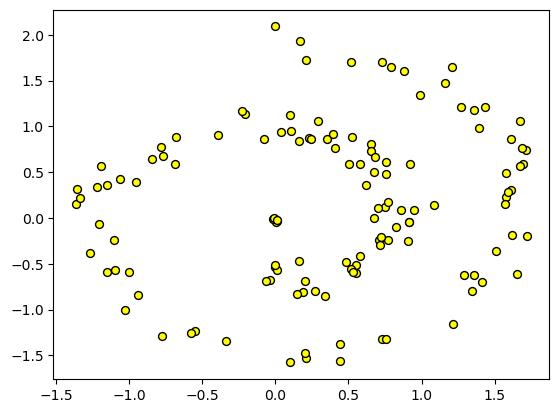

In [22]:
y_pred = D(X)
    
plt.scatter(y_pred[:, 0], y_pred[:, 1], 
            c="yellow", s=32, edgecolors="black", label = "Fitted distribution", zorder=1)

In [23]:
D.A_diagonal_matrix[:, 1].shape

torch.Size([500])

(array([354.,  81.,  39.,   0.,   0.,   0.,   0.,   0.,   0.,  26.]),
 array([ 0.41733428,  1.39054073,  2.36374717,  3.33695361,  4.31016006,
         5.2833665 ,  6.25657294,  7.22977938,  8.20298583,  9.17619227,
        10.14939871]),
 <BarContainer object of 10 artists>)

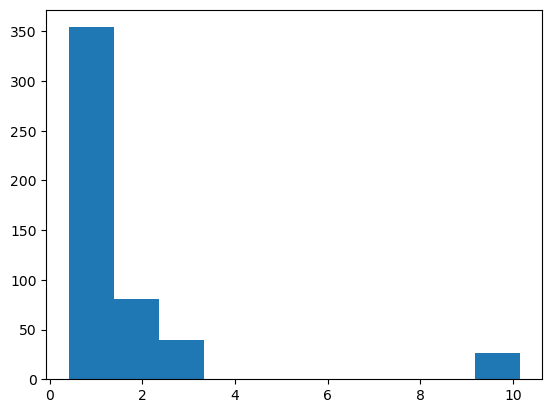

In [24]:
plt.hist(D.A_diagonal_matrix[:, 0].detach().numpy())

(array([ 10.,   6.,   4.,  40., 165., 166.,  84.,   7.,   7.,  11.]),
 array([-5.32135902, -4.2670573 , -3.21275559, -2.15845388, -1.10415217,
        -0.04985045,  1.00445126,  2.05875297,  3.11305469,  4.1673564 ,
         5.22165811]),
 <BarContainer object of 10 artists>)

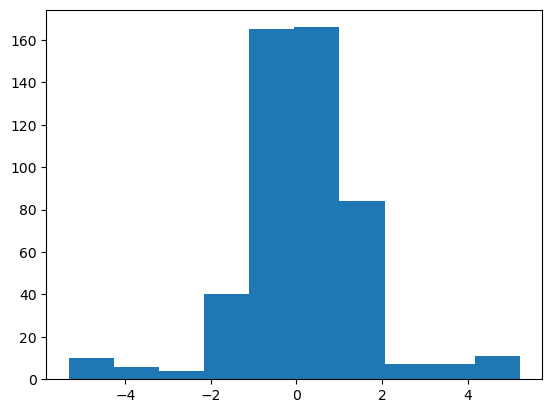

In [25]:
plt.hist(D.a[:, 1].detach().numpy())

(array([  5.,   7.,   1.,  69., 133., 223.,  45.,   4.,   4.,   9.]),
 array([-5.44495019e+00, -4.35614655e+00, -3.26734292e+00, -2.17853929e+00,
        -1.08973565e+00, -9.32022207e-04,  1.08787161e+00,  2.17667524e+00,
         3.26547888e+00,  4.35428251e+00,  5.44308614e+00]),
 <BarContainer object of 10 artists>)

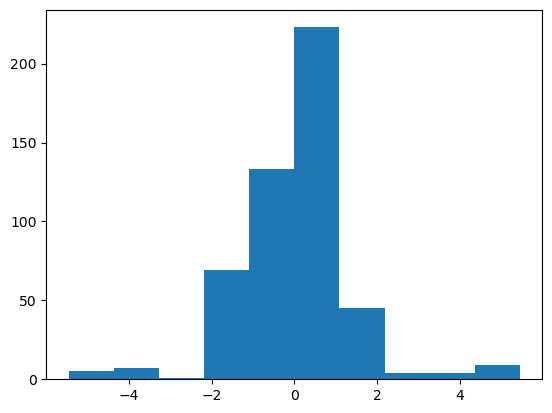

In [26]:
plt.hist(D.a[:, 0].detach().numpy())